# Fixed Point Reuse — Cubic 1D & Rank-1 RNN

**Cubic 1D system:** $\dot{x} = -x^3 + r\,x + m\,u(t)$, output $o = x$

**Rank-1 RNN:** $W_{rec} = mn^T$, effective scalar parameters $R_{eff} = n^Tm$, $M_{eff} = n^TW_{in}$

Both systems share the same bifurcation structure: bistability controlled by $r$ (or $R_{eff}$) with input sensitivity set by $m$ (or $M_{eff}$). The experiments below run in parallel on both systems using 4 canonical perturbations: $\Delta r / \Delta R = \pm 0.5$ and $\Delta m / \Delta M = \pm 2$.

**Output per system:** phase portrait + trajectories | gradient descent field | loss curves


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
import os

os.makedirs('plots', exist_ok=True)

C:\Users\Jasper\AppData\Local\Temp\ipykernel_9244\3333105310.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


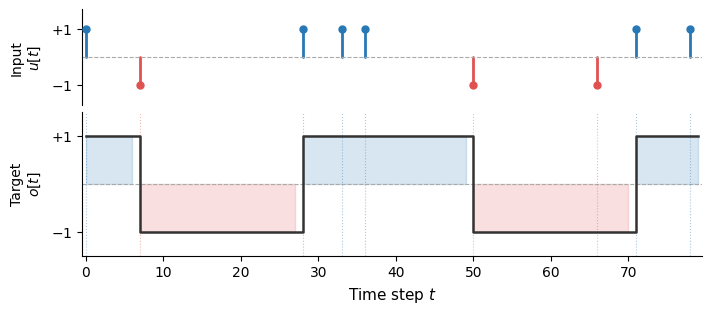

Saved: plots/flipflop_task.png


In [2]:
# ----------------------------------------------------------
# Flip-flop task illustration figure
# ----------------------------------------------------------
np.random.seed(3)
T_fig, p_fig = 80, 0.1

u_fig = np.zeros(T_fig)
o_fig = np.zeros(T_fig)
state_fig = np.random.choice([-1, 1])
for t in range(T_fig):
    if np.random.random() < p_fig:
        state_fig = np.random.choice([-1, 1])
        u_fig[t] = state_fig
    o_fig[t] = state_fig
t_ax = np.arange(T_fig)

fig, axes = plt.subplots(2, 1, figsize=(8, 3.2), sharex=True,
                          gridspec_kw={'height_ratios': [1, 1.5], 'hspace': 0.06})

# --- Input panel ---
ax = axes[0]
for t in range(T_fig):
    if u_fig[t] != 0:
        c = '#2878b5' if u_fig[t] > 0 else '#e05252'
        ax.plot([t, t], [0, u_fig[t]], color=c, linewidth=2.0, solid_capstyle='round')
        ax.plot(t, u_fig[t], 'o', color=c, markersize=5, zorder=5)
ax.axhline(0, color='#aaaaaa', linewidth=0.8, linestyle='--')
ax.set_ylim(-1.7, 1.7)
ax.set_yticks([-1, 1])
ax.set_yticklabels([r'$-1$', r'$+1$'], fontsize=10)
ax.set_ylabel('Input\n$u[t]$', fontsize=10, labelpad=6)
ax.set_xlim(-0.5, T_fig - 0.5)
ax.tick_params(bottom=False, left=True)
for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)

# --- Target output panel ---
ax = axes[1]
ax.step(t_ax, o_fig, where='post', color='#333333', linewidth=1.8, zorder=3)
ax.fill_between(t_ax, 0, o_fig, where=o_fig > 0, step='post',
                alpha=0.18, color='#2878b5')
ax.fill_between(t_ax, 0, o_fig, where=o_fig < 0, step='post',
                alpha=0.18, color='#e05252')
ax.axhline(0, color='#aaaaaa', linewidth=0.8, linestyle='--')
# Mark pulse times on target panel
for t in range(T_fig):
    if u_fig[t] != 0:
        c = '#2878b5' if u_fig[t] > 0 else '#e05252'
        ax.axvline(t, color=c, linewidth=0.8, alpha=0.4, linestyle=':')
ax.set_ylim(-1.5, 1.5)
ax.set_yticks([-1, 1])
ax.set_yticklabels([r'$-1$', r'$+1$'], fontsize=10)
ax.set_ylabel('Target\n$o[t]$', fontsize=10, labelpad=6)
ax.set_xlabel('Time step $t$', fontsize=11)
ax.set_xlim(-0.5, T_fig - 0.5)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('plots/flipflop_task.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/flipflop_task.png')


In [3]:
# ----------------------------------------------------------
# System + helpers
# ----------------------------------------------------------

dt    = 0.2
alpha = 1.0
p     = 0.1
T     = 200
B     = 64
CLIP  = 5.0
X_MAX = 8.0

def make_flipflop(B, T, p, seed=0):
    rng = np.random.default_rng(seed)
    u = np.zeros((B, T))
    o = np.zeros((B, T))
    for b in range(B):
        state = rng.choice([-1, 1])
        for t in range(T):
            if rng.random() < p:
                state = rng.choice([-1, 1])
                u[b, t] = state
            o[b, t] = state
    return (torch.tensor(u, dtype=torch.float32),
            torch.tensor(o, dtype=torch.float32))

def rollout(r, m, u_seq):
    x = torch.zeros(u_seq.shape[0])
    outs = []
    for t in range(u_seq.shape[1]):
        x = x + dt * (-x**3 + r * x + m * u_seq[:, t])
        x = x.clamp(-X_MAX, X_MAX)
        outs.append(alpha * x)
    return torch.stack(outs, dim=1)

def retrain_trajectory(r_init, m_init, U, O,
                        steps=500, lr=1e-2,
                        freeze_r=False, freeze_m=False):
    """Retrain and return (r_traj, m_traj, loss_traj)."""
    r = torch.tensor([r_init], requires_grad=(not freeze_r))
    m = torch.tensor([m_init], requires_grad=(not freeze_m))
    params = [p for p in [r, m] if p.requires_grad]
    opt = optim.RMSprop(params, lr=lr)
    r_traj, m_traj, loss_traj = [r_init], [m_init], []
    for _ in range(steps):
        opt.zero_grad()
        loss = ((rollout(r, m, U) - O) ** 2).mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(params, CLIP)
        opt.step()
        r_traj.append(r.item())
        m_traj.append(m.item())
        loss_traj.append(loss.item())
    return np.array(r_traj), np.array(m_traj), np.array(loss_traj)

def fold_curve(r_arr):
    r_pos = r_arr[r_arr >= 0]
    t = np.sqrt(r_pos / 3)
    return r_pos, -2*t**3, 2*t**3

def flip_boundary(r_arr):
    """Analytical flip boundary for the non-leaky integrator.
    At FP x*=√r with u=-1: x_new = x* - m·dt. Escape ⟺ m > √r/dt.
    This is the 'loss cliff': below it the network can't switch states."""
    r_pos = r_arr[r_arr >= 0]
    return r_pos, np.sqrt(r_pos) / dt

def make_background(ax, r_base, m_base, xlim=(-1.5, 4.0), ylim=None):
    r_grid = np.linspace(xlim[0], xlim[1], 400)
    r_fold, m_upper, m_lower = fold_curve(r_grid)
    r_flip, m_flip = flip_boundary(r_grid)
    ax.axvspan(xlim[0], 0.0, alpha=0.12, color='tomato')
    ax.axvspan(0.0, xlim[1], alpha=0.07, color='steelblue')
    ax.axvline(0, color='tomato', linewidth=1.8, linestyle='-',
               label='r=0 boundary')
    ax.axvline(r_base, color='gray', linewidth=1.0, linestyle=':',
               label=f'Base r={r_base:.2f}')
    ax.plot(r_fold, m_upper, 'k--', linewidth=1.0, label='Fold curve')
    ax.plot(r_fold, m_lower, 'k--', linewidth=1.0)
    ax.plot(r_flip, m_flip, 'm-', linewidth=2.0, zorder=4,
            label=r'Flip boundary $\sqrt{r}/dt$')
    ax.plot(r_base, m_base, '*', color='gold', markersize=14,
            markeredgecolor='k', zorder=5, label='Base model')
    ax.set_xlabel('r  (recurrent weight)', fontsize=11)
    ax.set_ylabel('m  (input weight)', fontsize=11)
    ax.set_xlim(*xlim)
    if ylim: ax.set_ylim(ylim)

def compute_grad_field(U, O, r_range, m_range):
    """Compute descent direction (-∂L/∂r, -∂L/∂m) and L on a grid.
    Returns: gr, gm (normalised unit vectors), lf (loss values).
    Grid layout: rows = m_range, cols = r_range (matches meshgrid convention)."""
    nr, nm = len(r_range), len(m_range)
    gr = np.zeros((nm, nr))
    gm = np.zeros((nm, nr))
    lf = np.zeros((nm, nr))
    for i, mv in enumerate(m_range):
        for j, rv in enumerate(r_range):
            r_t = torch.tensor([rv], requires_grad=True)
            m_t = torch.tensor([mv], requires_grad=True)
            loss = ((rollout(r_t, m_t, U) - O)**2).mean()
            loss.backward()
            gr[i, j] = -r_t.grad.item()
            gm[i, j] = -m_t.grad.item()
            lf[i, j] = loss.item()
    # normalise to unit length for clear arrow direction
    mag = np.sqrt(gr**2 + gm**2) + 1e-10
    return gr / mag, gm / mag, lf

print('System defined.')


System defined.


In [4]:
# ----------------------------------------------------------
# Base model — analytical r, 1D scan for m
# ----------------------------------------------------------
# Fixed points (u=0): ẋ=0  →  x*(−x*²+r)=0  →  x*=±√r
# Targets ±1  →  r = 1  (exact, no training needed)
# m: no closed form, do a fast 1D scan over the loss

torch.manual_seed(0)
U, O = make_flipflop(B, T, p, seed=0)

r_base = 1.0   # analytical

m_scan = np.linspace(0.5, 15.0, 300)
with torch.no_grad():
    r_t = torch.tensor([r_base])
    losses_scan = [((rollout(r_t, torch.tensor([float(mv)]), U) - O)**2).mean().item()
                   for mv in m_scan]
best_idx = int(np.argmin(losses_scan))
m_base   = float(m_scan[best_idx])

print(f'Base model: r={r_base:.4f} (analytical)  '
      f'm={m_base:.4f} (1D scan, loss={losses_scan[best_idx]:.4f})')


Base model: r=1.0000 (analytical)  m=6.2709 (1D scan, loss=0.1906)


In [5]:
# ----------------------------------------------------------
# Combined experiment: 4 corner perturbations
# All combinations of Δr = ±0.5  and  Δm = ±2
# ----------------------------------------------------------

perturbs = [
    (+0.5, -3.0, 'Δr+, Δm−', 'C0'),
]

trajs_4pt = []
print(f"{'label':>11}  {'r_start':>8}  {'m_start':>8}  {'r_end':>7}  {'m_end':>7}  {'loss':>8}")
print("-" * 65)
for dr, dm, label, color in perturbs:
    rt, mt, lt = retrain_trajectory(r_base + dr, m_base + dm, U, O)
    with torch.no_grad():
        loss_end = ((rollout(torch.tensor([rt[-1]]),
                             torch.tensor([mt[-1]]), U) - O)**2).mean().item()
    trajs_4pt.append((rt, mt, lt, label, color))
    print(f"{label:>11}  {r_base+dr:8.4f}  {m_base+dm:8.4f}  "
          f"{rt[-1]:7.4f}  {mt[-1]:7.4f}  {loss_end:8.5f}")

print('\nDone — run next cell for plots.')


      label   r_start   m_start    r_end    m_end      loss
-----------------------------------------------------------------
   Δr+, Δm−    1.5000    3.2709   0.7189   6.0123   0.17491

Done — run next cell for plots.


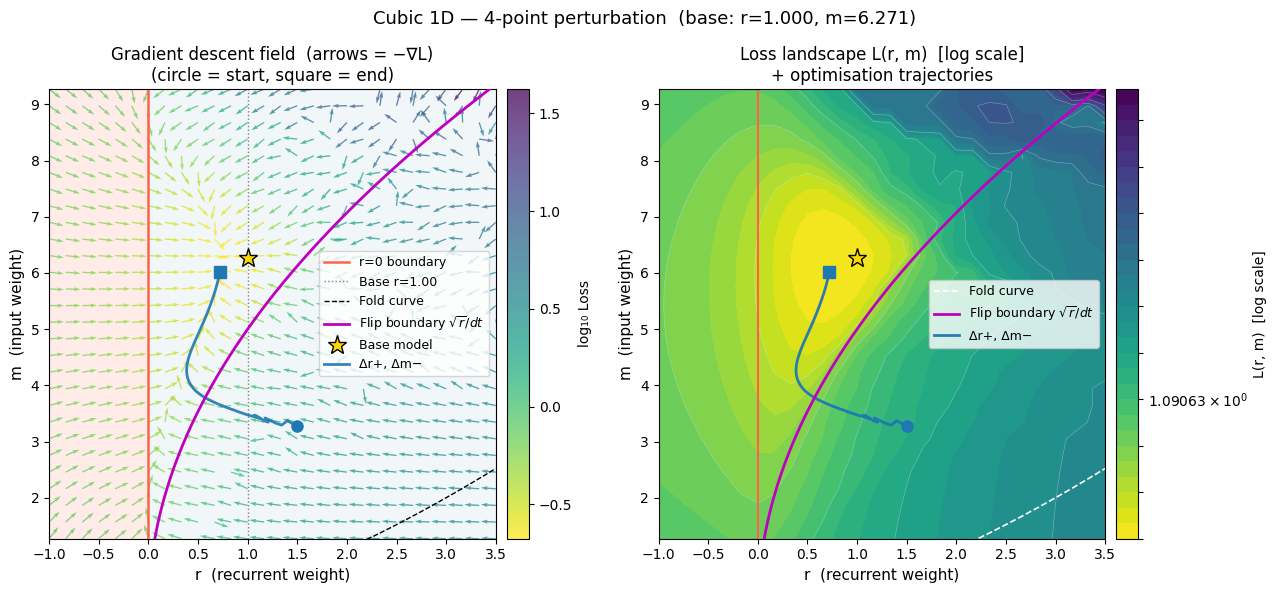

Saved: plots/cubic_4pt_combined.png


In [6]:
# ----------------------------------------------------------
# 2-panel figure
# Panel 1: gradient descent field + trajectories
# Panel 2: loss landscape L(r,m) — log scale — + trajectories
# ----------------------------------------------------------
from matplotlib.colors import LogNorm

U_gf, O_gf = make_flipflop(16, 100, p, seed=0)
r_rng = np.linspace(-1.0, 3.5, 28)
m_rng = np.linspace(m_base - 5, m_base + 3, 28)
gr, gm, lf = compute_grad_field(U_gf, O_gf, r_rng, m_rng)
RR, MM = np.meshgrid(r_rng, m_rng)

xlim_p = (-1.0, 3.5)
ylim_p = (m_base - 5, m_base + 3)

r_grid_p = np.linspace(xlim_p[0], xlim_p[1], 400)
r_flip_p, m_flip_p = flip_boundary(r_grid_p)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# ---- Panel 1: gradient descent field + trajectories ----
ax = axes[0]
make_background(ax, r_base, m_base, xlim=xlim_p, ylim=ylim_p)
lf_log = np.log10(np.maximum(lf, 1e-6))
q = ax.quiver(RR, MM, gr, gm, lf_log, cmap='viridis_r', alpha=0.75, scale=30, width=0.003)
plt.colorbar(q, ax=ax, label='log₁₀ Loss', pad=0.02)
for rt, mt, lt, label, color in trajs_4pt:
    ax.plot(rt, mt, color=color, linewidth=2.0, alpha=0.9, label=label)
    ax.plot(rt[0],  mt[0],  'o', color=color, markersize=8)
    ax.plot(rt[-1], mt[-1], 's', color=color, markersize=8)
ax.set_title('Gradient descent field  (arrows = −∇L)\n(circle = start, square = end)', fontsize=12)
ax.legend(fontsize=9)

# ---- Panel 2: log-scale loss landscape L(r,m) + trajectories ----
ax = axes[1]
lf_safe = np.maximum(lf, 1e-6)
lv = np.logspace(np.log10(lf_safe.min()), np.log10(lf_safe.max()), 30)
cf = ax.contourf(RR, MM, lf_safe, levels=lv, norm=LogNorm(vmin=lf_safe.min(), vmax=lf_safe.max()),
                 cmap='viridis_r')
plt.colorbar(cf, ax=ax, label='L(r, m)  [log scale]', pad=0.02)
ax.contour(RR, MM, lf_safe, levels=lv[::3], colors='white', linewidths=0.4, alpha=0.4)
# Fold curve
r_fold, m_upper, m_lower = fold_curve(r_rng[r_rng >= 0])
ax.plot(r_fold, m_upper, 'w--', linewidth=1.2, label='Fold curve')
ax.plot(r_fold, m_lower, 'w--', linewidth=1.2)
# Flip boundary (loss cliff)
ax.plot(r_flip_p, m_flip_p, 'm-', linewidth=2.0, zorder=4, label=r'Flip boundary $\sqrt{r}/dt$')
ax.axvline(0, color='tomato', linewidth=1.5, linestyle='-')
ax.plot(r_base, m_base, '*', color='gold', markersize=14, markeredgecolor='k', zorder=5)
for rt, mt, lt, label, color in trajs_4pt:
    ax.plot(rt, mt, color=color, linewidth=2.0, alpha=0.95, label=label)
    ax.plot(rt[0],  mt[0],  'o', color=color, markersize=8)
    ax.plot(rt[-1], mt[-1], 's', color=color, markersize=8)
ax.set_xlim(*xlim_p); ax.set_ylim(*ylim_p)
ax.set_xlabel('r  (recurrent weight)', fontsize=11)
ax.set_ylabel('m  (input weight)', fontsize=11)
ax.set_title('Loss landscape L(r, m)  [log scale]\n+ optimisation trajectories', fontsize=12)
ax.legend(fontsize=9)

fig.suptitle(f'Cubic 1D — 4-point perturbation  (base: r={r_base:.3f}, m={m_base:.3f})', fontsize=13)
plt.tight_layout()
plt.savefig('plots/cubic_4pt_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/cubic_4pt_combined.png')


# Rank-1 RNN — Analog of the r-m Phase Portrait

The rank-1 RNN implements:

$$r[t+1] = (1-\alpha)\,r[t] + \alpha\,\tanh\!\bigl(W\,r[t] + b + W_{in}\,u[t]\bigr)$$

With $W = mn^T$, substituting $W r = m\,(n^T r) = m\kappa$ gives the **exact** scalar reduction:

$$\boxed{\kappa[t+1] = (1-\alpha)\,\kappa[t] + \alpha\; n^T \tanh\!\bigl(m\,\kappa[t] + b + W_{in}\,u[t]\bigr)}$$

where $\kappa[t] = n^T r[t]$. Note $n^T$ is applied **outside** the tanh (not factored inside — tanh is nonlinear).

The two **effective scalar parameters** characterise the fixed-point structure via the mean-field approximation $n^T\tanh(\cdots) \approx \tanh(n^T(\cdots))$:
- $R_{eff} = n^T m$ — effective recurrent gain (bistable when $R_{eff} > 1$, analogous to $r > 0$)
- $M_{eff} = n^T W_{in}$ — effective input gain (analogous to $m$)

The experiments below track $(R_{eff}, M_{eff})$ trajectories during retraining — the direct analog of the $(r, m)$ plots above.


In [7]:
# ----------------------------------------------------------
# Rank-1 RNN — definitions and helpers
# ----------------------------------------------------------
import torch.nn as nn
import copy
import time

class RankOneRNN(nn.Module):
    def __init__(self, N, alpha, freeze_b=False):
        super().__init__()
        self.N       = N
        self.alpha   = alpha
        self.m   = nn.Parameter(torch.randn(N, 1) / np.sqrt(N))
        self.n   = nn.Parameter(torch.randn(N, 1) / np.sqrt(N))
        self.win = nn.Parameter(torch.randn(N, 1) / np.sqrt(N))
        if freeze_b:
            self.register_buffer('b', torch.zeros(N))
        else:
            self.b = nn.Parameter(torch.zeros(N))

    def forward(self, u):
        B = u.shape[0]
        r = torch.randn(B, self.N, device=u.device) / 3
        outs = []
        for t in range(u.shape[1]):
            kappa = r @ self.n
            phi   = torch.tanh(kappa @ self.m.T + self.b + u[:,t,:] @ self.win.T)
            r     = (1 - self.alpha) * r + self.alpha * phi
            outs.append(r @ self.n)
        return torch.cat(outs, dim=1)

def get_eff(rnn):
    n   = rnn.n.view(-1).detach()
    m   = rnn.m.view(-1).detach()
    win = rnn.win.view(-1).detach()
    return (n @ m).item(), (n @ win).item()

def zero_b_eff(rnn):
    """Project out n^T b from b so b_eff = 0. Called once after base training."""
    with torch.no_grad():
        n_vec = rnn.n.view(-1)
        b_eff = (n_vec @ rnn.b.data) / (n_vec @ n_vec)
        rnn.b.data -= b_eff * n_vec
    print(f'b_eff zeroed: was {b_eff.item():.4f}, residual = {(n_vec @ rnn.b.data).item():.2e}')

def perturb_M(rnn, delta_M):
    with torch.no_grad():
        n_hat = rnn.n.view(-1) / (rnn.n.view(-1) @ rnn.n.view(-1))
        rnn.win.data += (delta_M * n_hat).view(-1, 1)

def perturb_R(rnn, delta_R):
    with torch.no_grad():
        n_hat = rnn.n.view(-1) / (rnn.n.view(-1) @ rnn.n.view(-1))
        rnn.m.data += (delta_R * n_hat).view(-1, 1)

def retrain_rnn_traj(rnn_base, U_rnn, O_rnn, steps=4000, lr=2e-3,
                     freeze_b=True, R_min=None,
                     M_scale_fn=None, lr_M=None, verbose_steps=None):
    """Retrain (deep copy of rnn_base); return (R_eff, M_eff, loss, rnn_final).

    freeze_b     : freeze b during retraining (keeps b_eff=0 invariant)
    M_scale_fn   : callable(R, M) -> float; scales win.grad to boost M_eff ascent
    lr_M         : if set, uses separate RMSprop for win with this lr
    verbose_steps: set/list of step indices to print at (None = silent)
    """
    rnn = copy.deepcopy(rnn_base)
    rnn.n.requires_grad_(False)
    if freeze_b:
        if isinstance(rnn.b, nn.Parameter):
            rnn.b.requires_grad_(False)
    grad_params = [rnn.m, rnn.win]
    if not freeze_b and isinstance(rnn.b, nn.Parameter):
        grad_params.append(rnn.b)

    n_vec = rnn.n.view(-1).detach()
    n_hat = n_vec / (n_vec @ n_vec)

    if lr_M is not None:
        opts = [torch.optim.RMSprop([rnn.m], lr=lr),
                torch.optim.RMSprop([rnn.win], lr=lr_M)]
        if not freeze_b and isinstance(rnn.b, nn.Parameter):
            opts.append(torch.optim.RMSprop([rnn.b], lr=lr))
    else:
        opts = [torch.optim.RMSprop(grad_params, lr=lr)]

    R_traj, M_traj, L_traj = [], [], []
    t0 = time.perf_counter()
    for step in range(steps):
        R, M = get_eff(rnn)
        R_traj.append(R); M_traj.append(M)
        for opt in opts:
            opt.zero_grad()
        loss = ((rnn(U_rnn) - O_rnn)**2).mean()
        loss.backward()
        with torch.no_grad():
            for p in [rnn.m, rnn.win]:
                if p.grad is not None:
                    g = p.grad.view(-1)
                    p.grad.data = ((g @ n_hat) * n_hat).view_as(p)
            if M_scale_fn is not None and rnn.win.grad is not None:
                scale = M_scale_fn(R, M)
                rnn.win.grad.data *= scale
        torch.nn.utils.clip_grad_norm_(grad_params, 5.0)
        L_traj.append(loss.item())
        for opt in opts:
            opt.step()
        if R_min is not None:
            with torch.no_grad():
                R_curr, _ = get_eff(rnn)
                if R_curr < R_min:
                    perturb_R(rnn, R_min - R_curr)
        if verbose_steps is not None and step in verbose_steps:
            elapsed = time.perf_counter() - t0
            print(f'    step {step:4d}  t={elapsed:5.1f}s  '
                  f'R={R:.3f}  M={M:.3f}  loss={loss.item():.4f}')
    R, M = get_eff(rnn)
    R_traj.append(R); M_traj.append(M)
    return np.array(R_traj), np.array(M_traj), np.array(L_traj), rnn

def run_experiment(rnn_base_exp, perturbs, U_rnn, O_rnn,
                   steps=4000, lr=2e-3, **kwargs):
    """Run retraining for all perturbations; return list of (Rt, Mt, Lt, label, color)."""
    trajs = []
    print(f"{'label':>36}  {'R_start':>7}  {'M_start':>7}  {'R_end':>7}  {'M_end':>7}  {'loss':>8}  {'time':>6}")
    print("-" * 100)
    total_t0 = time.perf_counter()
    for dR, dM, label, color in perturbs:
        traj_t0 = time.perf_counter()
        rnn_p = copy.deepcopy(rnn_base_exp)
        perturb_R(rnn_p, dR)
        perturb_M(rnn_p, dM)
        Rt, Mt, Lt, rnn_f = retrain_rnn_traj(rnn_p, U_rnn, O_rnn,
                                               steps=steps, lr=lr, **kwargs)
        with torch.no_grad():
            loss_end = ((rnn_f(U_rnn) - O_rnn)**2).mean().item()
        traj_elapsed = time.perf_counter() - traj_t0
        trajs.append((Rt, Mt, Lt, label, color))
        print(f"{label:>36}  {Rt[0]:7.3f}  {Mt[0]:7.3f}  "
              f"{Rt[-1]:7.3f}  {Mt[-1]:7.3f}  {loss_end:8.5f}  {traj_elapsed:5.1f}s")
    total_elapsed = time.perf_counter() - total_t0
    print(f'\nTotal: {total_elapsed:.1f}s  ({total_elapsed/len(perturbs):.1f}s/trajectory)')
    return trajs

def plot_reinit_grid(trajs, title='', save_path=None):
    from matplotlib.colors import LogNorm
    FS_LABEL = 18; FS_TICK = 16; FS_PANEL = 21
    n_rows = len(R_tests)
    fig, axes = plt.subplots(n_rows, 2, figsize=(13, 5 * n_rows))
    panel_letters = list('abcdef')
    panel_idx = 0
    for row, (R_test, col) in enumerate(zip(R_tests, colors)):
        traj_above = trajs[row * 2]
        traj_below = trajs[row * 2 + 1]
        Rt_a, Mt_a, _, _, _ = traj_above
        Rt_b, Mt_b, _, _, _ = traj_below
        mc = mcrit_at_R(R_test, alpha_rnn=rnn_base.alpha)
        for col_idx, (panel, title_suffix) in enumerate([
                ('quiver',  'Gradient field'),
                ('contour', 'Loss landscape')]):
            ax = axes[row, col_idx]
            if panel == 'quiver':
                make_background_rnn(ax, R_base_rnn, M_base_rnn,
                                    xlim=xlim_r, ylim=ylim_r, alpha_rnn=rnn_base.alpha)
                q = ax.quiver(RR_r, MM_r, gr_r, gm_r, lf_r_log,
                              cmap='viridis_r', alpha=0.7, scale=30, width=0.003)
                cb = plt.colorbar(q, ax=ax, pad=0.02)
                cb.set_label(r'$\log_{10}$ Loss', fontsize=FS_TICK)
                cb.ax.tick_params(labelsize=FS_TICK)
            else:
                cf = ax.contourf(RR_r, MM_r, lf_r_safe, levels=lv_r,
                                 norm=LogNorm(vmin=lf_r_safe.min(), vmax=lf_r_safe.max()),
                                 cmap='viridis_r')
                cb = plt.colorbar(cf, ax=ax, pad=0.02)
                cb.set_label(r'$L(R_\mathrm{eff},\,M_\mathrm{eff})$', fontsize=FS_TICK)
                cb.ax.tick_params(labelsize=FS_TICK)
                ax.contour(RR_r, MM_r, lf_r_safe, levels=lv_r[::3],
                           colors='white', linewidths=0.4, alpha=0.4)
                ax.plot(R_fc,  M_fc, 'w--', linewidth=1.2, label='Fold curve')
                ax.plot(R_fc, -M_fc, 'w--', linewidth=1.2)
                ax.plot(R_flip_r,  M_flip_r, 'm-', linewidth=2.0, zorder=4,
                        label='Flip boundary')
                ax.plot(R_flip_r, -M_flip_r, 'm-', linewidth=2.0, zorder=4)
                ax.axvline(1.0, color='tomato', linewidth=1.5)
                ax.plot(R_base_rnn, M_base_rnn, '*', color='gold', markersize=14,
                        markeredgecolor='k', zorder=5)
                ax.set_xlim(*xlim_r); ax.set_ylim(*ylim_r)
            ax.set_xlabel(r'$R_\mathrm{eff} = n^\top m$', fontsize=FS_LABEL)
            ax.set_ylabel(r'$M_\mathrm{eff} = n^\top W_\mathrm{in}$', fontsize=FS_LABEL)
            ax.tick_params(labelsize=FS_TICK)
            ax.plot(Rt_a, Mt_a, color=col, linewidth=2.0, linestyle='-',
                    alpha=0.95, label=f'Above ($M_0={Mt_a[0]:.2f}$)')
            ax.plot(Rt_a[0],  Mt_a[0],  'o', color=col, markersize=9, zorder=6)
            ax.plot(Rt_a[-1], Mt_a[-1], 's', color=col, markersize=9, zorder=6)
            ax.plot(Rt_b, Mt_b, color=col, linewidth=2.0, linestyle='--',
                    alpha=0.75, label=f'Below ($M_0={Mt_b[0]:.2f}$)')
            ax.plot(Rt_b[0],  Mt_b[0],  'o', color=col, markersize=9,
                    zorder=6, markerfacecolor='white', markeredgewidth=1.5)
            ax.plot(Rt_b[-1], Mt_b[-1], 's', color=col, markersize=9,
                    zorder=6, markerfacecolor='white', markeredgewidth=1.5)
            ax.set_title(f'$R_{{\\mathrm{{test}}}}={R_test}$,  '
                         f'$M_{{\\mathrm{{crit}}}}={mc:.2f}$ — {title_suffix}',
                         fontsize=15)
            ax.text(0.02, 0.97, f'({panel_letters[panel_idx]})',
                    transform=ax.transAxes, fontsize=FS_PANEL,
                    fontweight='bold', va='top', ha='left',
                    bbox=dict(boxstyle='square,pad=0.2', facecolor='white',
                              alpha=0.75, edgecolor='none'))
            panel_idx += 1
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def fold_curve_rnn(y_arr):
    R = np.cosh(y_arr)**2
    M = y_arr - np.sinh(y_arr) * np.cosh(y_arr)
    return R, M

def flip_boundary_rnn(R_arr, alpha_rnn=0.5):
    R_bistable = R_arr[R_arr > 1.0]
    M_crit = []
    for Rv in R_bistable:
        kappa = 0.5
        for _ in range(500):
            kappa = np.tanh(Rv * kappa)
        ratio = (1 - alpha_rnn) / alpha_rnn * kappa
        if abs(ratio) >= 1.0:
            M_crit.append(np.nan)
        else:
            M_crit.append(np.arctanh(kappa) + np.arctanh(ratio))
    return R_bistable, np.array(M_crit)

def make_background_rnn(ax, R_base, M_base, xlim=None, ylim=None, alpha_rnn=0.5):
    y = np.linspace(-2.5, 2.5, 400)
    R_fold, M_fold = fold_curve_rnn(y)
    xl = xlim if xlim else (max(-0.5, R_base - 1.5), R_base + 2.0)
    R_flip, M_flip = flip_boundary_rnn(np.linspace(xl[0], xl[1], 400), alpha_rnn)
    ax.axvspan(xl[0], 0.99, alpha=0.12, color='tomato')
    ax.axvspan(1.0, xl[1], alpha=0.07, color='steelblue')
    ax.axvline(1.0, color='tomato', linewidth=1.8, linestyle='-', label='R=1 boundary')
    ax.axvline(R_base, color='gray', linewidth=1.0, linestyle=':', label=f'Base R={R_base:.2f}')
    ax.plot(R_fold,  M_fold, 'k--', linewidth=1.0, label='Fold curve')
    ax.plot(R_fold, -M_fold, 'k--', linewidth=1.0)
    ax.plot(R_flip,  M_flip, 'm-', linewidth=2.0, zorder=4, label='Flip boundary')
    ax.plot(R_flip, -M_flip, 'm-', linewidth=2.0, zorder=4)
    ax.plot(R_base, M_base, '*', color='gold', markersize=14,
            markeredgecolor='k', zorder=5, label='Base model')
    ax.set_xlabel('$R_{eff} = n^T m$', fontsize=11)
    ax.set_ylabel('$M_{eff} = n^T W_{in}$', fontsize=11)
    ax.set_xlim(*xl)
    if ylim: ax.set_ylim(ylim)

def compute_grad_field_rnn(rnn_ref, U_rnn, O_rnn, R_range, M_range):
    n_vec = rnn_ref.n.view(-1).detach().clone()
    n_hat = n_vec / (n_vec @ n_vec)
    R0, M0 = get_eff(rnn_ref)
    nr, nm = len(R_range), len(M_range)
    gr = np.zeros((nm, nr))
    gm_arr = np.zeros((nm, nr))
    lf = np.zeros((nm, nr))
    for i, Mv in enumerate(M_range):
        for j, Rv in enumerate(R_range):
            rnn_g = copy.deepcopy(rnn_ref)
            perturb_R(rnn_g, Rv - R0)
            perturb_M(rnn_g, Mv - M0)
            for p in rnn_g.parameters():
                p.requires_grad_(True)
                if p.grad is not None: p.grad.zero_()
            loss = ((rnn_g(U_rnn) - O_rnn)**2).mean()
            loss.backward()
            gr[i, j]     = -(rnn_g.m.grad.view(-1)   @ n_hat).item()
            gm_arr[i, j] = -(rnn_g.win.grad.view(-1) @ n_hat).item()
            lf[i, j]     = loss.item()
    mag = np.sqrt(gr**2 + gm_arr**2) + 1e-10
    return gr / mag, gm_arr / mag, lf

print('Rank-1 RNN helpers defined.')


Rank-1 RNN helpers defined.


In [8]:
# ----------------------------------------------------------
# Rank-1 RNN — data setup (run this once)
# ----------------------------------------------------------
import torch.nn as nn
import copy

B_rnn, T_rnn, p_rnn = 64, 200, 0.1
torch.manual_seed(0)
U_rnn_np, O_rnn_np = make_flipflop(B_rnn, T_rnn, p_rnn, seed=0)
U_rnn = U_rnn_np.unsqueeze(-1)   # (B, T, 1)  — RNN expects 3D input
O_rnn = O_rnn_np                  # (B, T)

print(f'Data ready: U_rnn {tuple(U_rnn.shape)}, O_rnn {tuple(O_rnn.shape)}')

Data ready: U_rnn (64, 200, 1), O_rnn (64, 200)


In [9]:
# ----------------------------------------------------------
# Base Rank-1 RNN — train with b free (main model used downstream)
# Records (R_eff, M_eff) trajectory every 10 epochs for comparison plot.
# ----------------------------------------------------------
torch.manual_seed(0)

rnn_base = RankOneRNN(N=100, alpha=0.5, freeze_b=False)
opt_base  = torch.optim.Adam(rnn_base.parameters(), lr=1e-2)

R_traj_bfree, M_traj_bfree, L_traj_bfree = [], [], []
for epoch in range(3000):
    if epoch % 10 == 0:
        R, M = get_eff(rnn_base)
        R_traj_bfree.append(R); M_traj_bfree.append(M)
    opt_base.zero_grad()
    loss = ((rnn_base(U_rnn) - O_rnn)**2).mean()
    loss.backward()
    opt_base.step()
    if epoch % 10 == 0:
        L_traj_bfree.append(loss.item())
    if epoch % 1000 == 0:
        R, M = get_eff(rnn_base)
        print(f'Epoch {epoch:4d}  loss={loss.item():.4f}  R_eff={R:.4f}  M_eff={M:.4f}')

R, M = get_eff(rnn_base)
R_traj_bfree.append(R); M_traj_bfree.append(M)
R_traj_bfree = np.array(R_traj_bfree)
M_traj_bfree = np.array(M_traj_bfree)
L_traj_bfree = np.array(L_traj_bfree)

# Save raw (pre-zeroed) copy for Exp 1 (b not frozen during retraining)
rnn_base_raw = copy.deepcopy(rnn_base)

zero_b_eff(rnn_base)
R_base_rnn, M_base_rnn = get_eff(rnn_base)
print(f'\nBase RNN (b free, b_eff zeroed): R_eff={R_base_rnn:.4f}  M_eff={M_base_rnn:.4f}')


Epoch    0  loss=1.0391  R_eff=-0.1981  M_eff=-0.0603
Epoch 1000  loss=0.0622  R_eff=1.6689  M_eff=5.6927
Epoch 2000  loss=0.0807  R_eff=1.5836  M_eff=7.0391
b_eff zeroed: was -0.0822, residual = 0.00e+00

Base RNN (b free, b_eff zeroed): R_eff=1.4980  M_eff=7.6000


b=0 frozen final: R_eff=0.8641  M_eff=6.2268


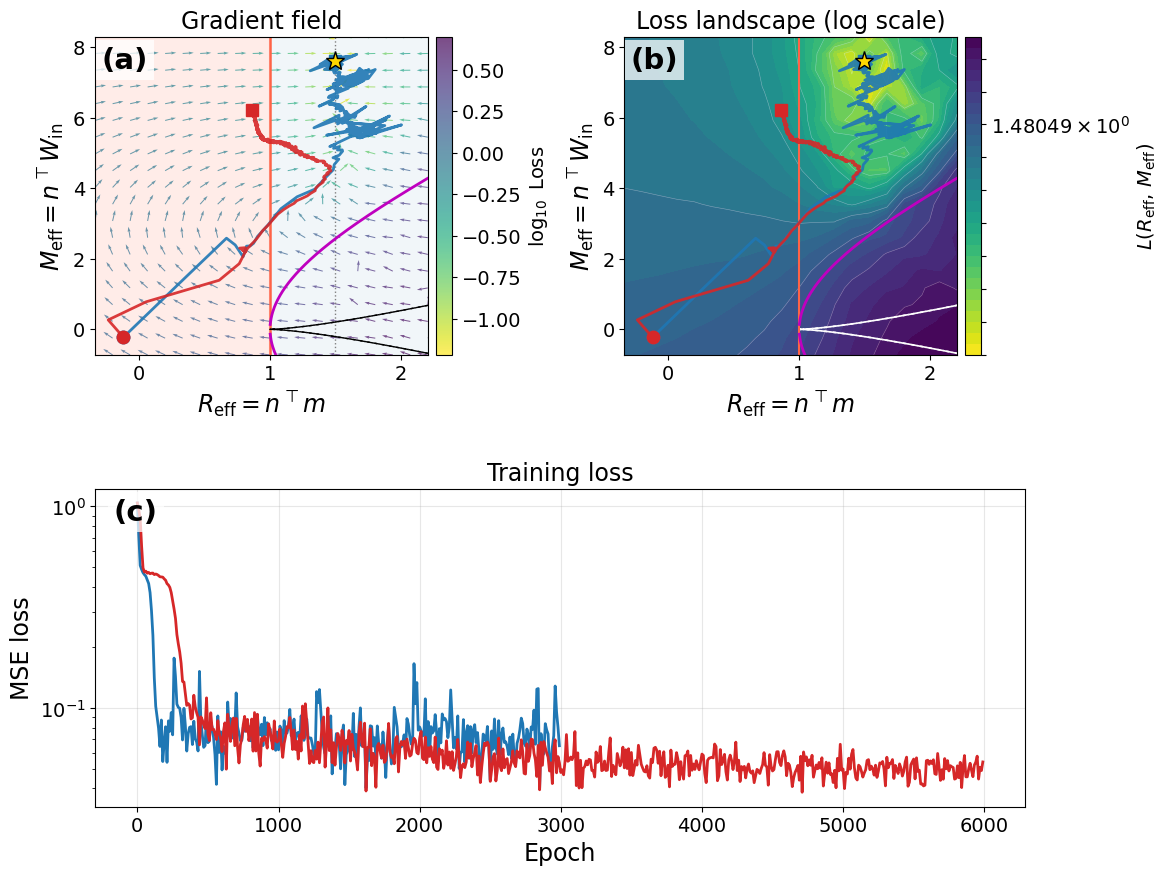

Saved: plots/rnn_base_training_comparison.png


In [10]:
# ----------------------------------------------------------
# Base training comparison: b free vs b=0 frozen
# ----------------------------------------------------------
from matplotlib.colors import LogNorm

torch.manual_seed(0)
rnn_bfrozen = RankOneRNN(N=100, alpha=0.5, freeze_b=True)
opt_frozen  = torch.optim.Adam(rnn_bfrozen.parameters(), lr=3e-3)

R_traj_bfrz, M_traj_bfrz, L_traj_bfrz = [], [], []
for epoch in range(6000):
    if epoch % 10 == 0:
        R, M = get_eff(rnn_bfrozen)
        R_traj_bfrz.append(R); M_traj_bfrz.append(M)
    opt_frozen.zero_grad()
    loss = ((rnn_bfrozen(U_rnn) - O_rnn)**2).mean()
    loss.backward()
    opt_frozen.step()
    if epoch % 10 == 0:
        L_traj_bfrz.append(loss.item())

R, M = get_eff(rnn_bfrozen)
R_traj_bfrz.append(R); M_traj_bfrz.append(M)
R_traj_bfrz = np.array(R_traj_bfrz)
M_traj_bfrz = np.array(M_traj_bfrz)
L_traj_bfrz = np.array(L_traj_bfrz)
print(f'b=0 frozen final: R_eff={R:.4f}  M_eff={M:.4f}')

# ---- background grid (use rnn_base as reference) ----
U_gf_cmp = U_rnn[:8]; O_gf_cmp = O_rnn[:8]
all_R = np.concatenate([R_traj_bfree, R_traj_bfrz])
all_M = np.concatenate([M_traj_bfree, M_traj_bfrz])
xlim_cmp = (min(all_R.min(), 0.0) - 0.1, all_R.max() + 0.2)
ylim_cmp = (all_M.min() - 0.5,            all_M.max() + 0.5)

R_rng_cmp = np.linspace(xlim_cmp[0], xlim_cmp[1], 20)
M_rng_cmp = np.linspace(ylim_cmp[0], ylim_cmp[1], 20)
gr_c, gm_c, lf_c = compute_grad_field_rnn(rnn_base, U_gf_cmp, O_gf_cmp,
                                            R_rng_cmp, M_rng_cmp)
RR_c, MM_c = np.meshgrid(R_rng_cmp, M_rng_cmp)
lf_c_safe = np.maximum(lf_c, 1e-6)
lf_c_log  = np.log10(lf_c_safe)
lv_c = np.logspace(np.log10(lf_c_safe.min()), np.log10(lf_c_safe.max()), 30)

R_flip_c, M_flip_c = flip_boundary_rnn(np.linspace(xlim_cmp[0], xlim_cmp[1], 400),
                                         alpha_rnn=rnn_base.alpha)
y_fc = np.linspace(-2.5, 2.5, 400)
R_fc, M_fc = fold_curve_rnn(y_fc)

from matplotlib.gridspec import GridSpec
FS_LABEL = 17; FS_TICK = 14; FS_PANEL = 21
fig = plt.figure(figsize=(12, 10))
gs  = GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.32)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, :])

for ax, (field_type, field_data), panel_letter in zip(
        [ax_a, ax_b],
        [('quiver', lf_c_log), ('contour', lf_c_safe)],
        ['a', 'b']):
    if field_type == 'quiver':
        make_background_rnn(ax, R_base_rnn, M_base_rnn,
                            xlim=xlim_cmp, ylim=ylim_cmp, alpha_rnn=rnn_base.alpha)
        q = ax.quiver(RR_c, MM_c, gr_c, gm_c, field_data, cmap='viridis_r',
                      alpha=0.7, scale=30, width=0.003)
        cb = plt.colorbar(q, ax=ax, pad=0.02)
        cb.set_label(r'$\log_{10}$ Loss', fontsize=FS_TICK)
        cb.ax.tick_params(labelsize=FS_TICK)
        panel_title = 'Gradient field'
    else:
        cf = ax.contourf(RR_c, MM_c, field_data, levels=lv_c,
                         norm=LogNorm(vmin=lf_c_safe.min(), vmax=lf_c_safe.max()),
                         cmap='viridis_r')
        cb = plt.colorbar(cf, ax=ax, pad=0.02)
        cb.set_label(r'$L(R_\mathrm{eff},\,M_\mathrm{eff})$', fontsize=FS_TICK)
        cb.ax.tick_params(labelsize=FS_TICK)
        ax.contour(RR_c, MM_c, field_data, levels=lv_c[::3],
                   colors='white', linewidths=0.4, alpha=0.4)
        ax.plot(R_fc,  M_fc, 'w--', linewidth=1.2)
        ax.plot(R_fc, -M_fc, 'w--', linewidth=1.2)
        ax.plot(R_flip_c,  M_flip_c, 'm-', linewidth=2.0, zorder=4)
        ax.plot(R_flip_c, -M_flip_c, 'm-', linewidth=2.0, zorder=4)
        ax.axvline(1.0, color='tomato', linewidth=1.5)
        ax.plot(R_base_rnn, M_base_rnn, '*', color='gold', markersize=14,
                markeredgecolor='k', zorder=5)
        ax.set_xlim(*xlim_cmp); ax.set_ylim(*ylim_cmp)
        panel_title = 'Loss landscape (log scale)'
    ax.plot(R_traj_bfree, M_traj_bfree, color='C0', linewidth=2.0, alpha=0.9)
    ax.plot(R_traj_bfree[0],  M_traj_bfree[0],  'o', color='C0', markersize=9)
    ax.plot(R_traj_bfree[-1], M_traj_bfree[-1], 's', color='C0', markersize=9)
    ax.plot(R_traj_bfrz, M_traj_bfrz, color='C3', linewidth=2.0, alpha=0.9)
    ax.plot(R_traj_bfrz[0],  M_traj_bfrz[0],  'o', color='C3', markersize=9)
    ax.plot(R_traj_bfrz[-1], M_traj_bfrz[-1], 's', color='C3', markersize=9)
    ax.set_xlabel(r'$R_\mathrm{eff} = n^\top m$', fontsize=FS_LABEL)
    ax.set_ylabel(r'$M_\mathrm{eff} = n^\top W_\mathrm{in}$', fontsize=FS_LABEL)
    ax.tick_params(labelsize=FS_TICK)
    ax.set_title(panel_title, fontsize=FS_LABEL)
    ax.text(0.02, 0.97, f'({panel_letter})',
            transform=ax.transAxes, fontsize=FS_PANEL, fontweight='bold',
            va='top', ha='left',
            bbox=dict(boxstyle='square,pad=0.2', facecolor='white', alpha=0.75, edgecolor='none'))

epochs_free = np.arange(len(L_traj_bfree)) * 10
epochs_frz  = np.arange(len(L_traj_bfrz))  * 10
ax_c.plot(epochs_free, L_traj_bfree, color='C0', linewidth=2.0)
ax_c.plot(epochs_frz,  L_traj_bfrz,  color='C3', linewidth=2.0)
ax_c.set_xlabel('Epoch', fontsize=FS_LABEL)
ax_c.set_ylabel('MSE loss', fontsize=FS_LABEL)
ax_c.tick_params(labelsize=FS_TICK)
ax_c.set_yscale('log')
ax_c.set_title('Training loss', fontsize=FS_LABEL)
ax_c.grid(True, alpha=0.3)
ax_c.text(0.02, 0.97, '(c)',
          transform=ax_c.transAxes, fontsize=FS_PANEL, fontweight='bold',
          va='top', ha='left',
          bbox=dict(boxstyle='square,pad=0.2', facecolor='white', alpha=0.75, edgecolor='none'))

plt.savefig('plots/rnn_base_training_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/rnn_base_training_comparison.png')

## TA Question: Can an RNN learn with W_rec=0, W_in=0, no bias?

**Theoretical answer (by hand):**

With $m=0$, $W_{in}=0$, $b=0$, the pre-tanh input at every step is $h[t] = m\kappa[t] + b + W_{in}u[t] = 0$, so $\phi[t] = \tanh(0) = 0$ and the hidden state evolves as:
$$r[t+1] = (1-\alpha)\,r[t]$$
decaying exponentially from its initial value regardless of the input.

**Case 1 — $r[0]=0$:** Every $r[t]=0$, every output $=0$, every gradient is zero. No parameters update; the network cannot learn at all.

**Case 2 — $r[0]\neq 0$ (random init):** Hidden state decays as $(1-\alpha)^t r[0]$, producing non-zero outputs and a non-zero loss. The gradient w.r.t. $W_{in}$ at this initialization is:
$$\frac{\partial L}{\partial W_{in}} = \sum_t \alpha\,\frac{\partial L}{\partial r[t+1]}\,u[t]^T \cdot \underbrace{\mathrm{sech}^2(h[t])}_{=1 \;\text{at}\; h=0}$$
which is non-zero as long as the decaying hidden state produces a loss signal. So *some* learning is possible, but it is driven entirely by the initial transient — once $r$ decays to near zero the gradient vanishes.

**Conclusion:** Learning requires non-zero $r[0]$. A small but non-zero initialization of $m$ and $W_{in}$ is sufficient to bootstrap the network beyond this transient into a self-sustaining gradient signal.

**Numerical verification:** Three runs below compare exact-zero, small non-zero, and normal random initialization of $m$ and $W_{in}$ (all with $b=0$ frozen, lr=1e-3).


                              config   R_init   M_init    R_fin    M_fin      loss    time
------------------------------------------------------------------------------------------
                zero  (R=0.0, M=0.0)   0.0000   0.0000   1.1249   6.2589   0.07218  313.4s
                small (R=0.1, M=0.1)   0.1000   0.1000   1.3922   6.2861   0.08782  312.0s
               normal (R=1.0, M=1.0)   1.0000   1.0000   1.0077   4.6194   0.06595  313.1s
            bistable (R=1.1, M=1.41)   1.1000   1.4065   0.8974   0.5185   0.06652  326.5s


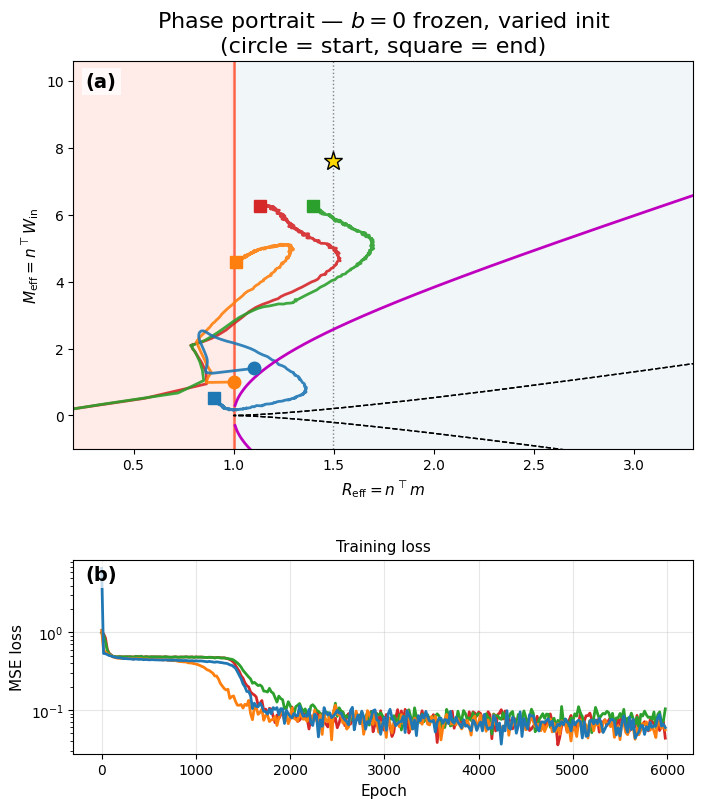

Saved: plots/rnn_ta_init_comparison.png


In [15]:
# ----------------------------------------------------------
# TA question -- base training from various initializations, b=0 frozen
# Optimizer: Adam lr=1e-3 (same as original base training, NOT retraining)
# ----------------------------------------------------------
mc_11 = mcrit_at_R(1.1, alpha_rnn=rnn_base.alpha)

configs = [
    ('zero  (R=0.0, M=0.0)',                       0.0, 0.0,          'C3'),
    ('small (R=0.1, M=0.1)',                       0.1, 0.1,          'C2'),
    ('normal (R=1.0, M=1.0)',                      1.0, 1.0,          'C1'),
    (f'bistable (R=1.1, M={mc_11+0.3:.2f})',       1.1, mc_11 + 0.3, 'C0'),
]

n_epochs_ta  = 6000
record_every = 20
_ylim_ta = (-1, M_base_rnn + 3)

print(f"{'config':>36}  {'R_init':>7}  {'M_init':>7}  {'R_fin':>7}  {'M_fin':>7}  {'loss':>8}  {'time':>6}")
print('-' * 90)

all_trajs = []
for label, R_init, M_init, col in configs:
    torch.manual_seed(0)
    rnn_ta = RankOneRNN(N=100, alpha=0.5, freeze_b=True)
    with torch.no_grad():
        rnn_ta.m.data.zero_()
        rnn_ta.win.data.zero_()
    perturb_R(rnn_ta, R_init)
    perturb_M(rnn_ta, M_init)
    R_check, M_check = get_eff(rnn_ta)

    opt_ta = torch.optim.Adam(rnn_ta.parameters(), lr=1e-3)
    R_t, M_t, L_t = [], [], []
    t0 = time.perf_counter()
    for epoch in range(n_epochs_ta):
        if epoch % record_every == 0:
            R, M = get_eff(rnn_ta)
            R_t.append(R); M_t.append(M)
        opt_ta.zero_grad()
        loss = ((rnn_ta(U_rnn) - O_rnn)**2).mean()
        loss.backward()
        opt_ta.step()
        if epoch % record_every == 0:
            L_t.append(loss.item())
    elapsed = time.perf_counter() - t0
    R_fin, M_fin = get_eff(rnn_ta)
    with torch.no_grad():
        loss_fin = ((rnn_ta(U_rnn) - O_rnn)**2).mean().item()
    print(f'{label:>36}  {R_check:7.4f}  {M_check:7.4f}  {R_fin:7.4f}  {M_fin:7.4f}  {loss_fin:8.5f}  {elapsed:5.1f}s')
    all_trajs.append((np.array(R_t), np.array(M_t), np.array(L_t), label, col))

# ---- Phase portrait ----
FS_LABEL = 11; FS_TICK = 10; FS_PANEL = 14
fig, axes = plt.subplots(2, 1, figsize=(8, 9),
                          gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.38})

ax = axes[0]
make_background_rnn(ax, R_base_rnn, M_base_rnn,
                    xlim=xlim_r, ylim=_ylim_ta, alpha_rnn=rnn_base.alpha)
epochs_ax = np.arange(n_epochs_ta // record_every) * record_every
for Rt, Mt, Lt, label, col in all_trajs:
    ax.plot(Rt, Mt, color=col, linewidth=2.0, alpha=0.9)
    ax.plot(Rt[0],  Mt[0],  'o', color=col, markersize=9, zorder=6)
    ax.plot(Rt[-1], Mt[-1], 's', color=col, markersize=9, zorder=6)
ax.set_xlabel(r'$R_\mathrm{eff} = n^\top m$', fontsize=FS_LABEL)
ax.set_ylabel(r'$M_\mathrm{eff} = n^\top W_\mathrm{in}$', fontsize=FS_LABEL)
ax.tick_params(labelsize=FS_TICK)
ax.set_title('Phase portrait — $b=0$ frozen, varied init\n(circle = start, square = end)', fontsize=16)
ax.text(0.02, 0.97, '(a)', transform=ax.transAxes, fontsize=FS_PANEL,
        fontweight='bold', va='top', ha='left',
        bbox=dict(boxstyle='square,pad=0.2', facecolor='white', alpha=0.75, edgecolor='none'))

ax = axes[1]
for Rt, Mt, Lt, label, col in all_trajs:
    ax.plot(epochs_ax[:len(Lt)], Lt, color=col, linewidth=2.0)
ax.set_xlabel('Epoch', fontsize=FS_LABEL)
ax.set_ylabel('MSE loss', fontsize=FS_LABEL)
ax.tick_params(labelsize=FS_TICK)
ax.set_yscale('log')
ax.set_title('Training loss', fontsize=FS_LABEL)
ax.grid(True, alpha=0.3)
ax.text(0.02, 0.97, '(b)', transform=ax.transAxes, fontsize=FS_PANEL,
        fontweight='bold', va='top', ha='left',
        bbox=dict(boxstyle='square,pad=0.2', facecolor='white', alpha=0.75, edgecolor='none'))

plt.savefig('plots/rnn_ta_init_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/rnn_ta_init_comparison.png')

## TA Follow-up: Strong Synapse Initialisation

The TA pointed out that the symmetry-breaking argument only bites when weights are small.
With standard initialisation ($m, n \sim \mathcal{N}(0, 1/N)$), the effective parameters
at initialisation satisfy $R_{\mathrm{eff}} \approx 0$,
placing the network squarely in the flat symmetric region where the loss gradient
along $M_{\mathrm{eff}}$ is zero.

If instead $n \sim \mathcal{N}(0, 1)$ (keeping $m \sim \mathcal{N}(0, 1/N)$), then
$\mathrm{Var}(R_{\mathrm{eff}}) = N \cdot 1 \cdot \frac{1}{N} = 1$,
so $R_{\mathrm{eff}}$ starts at $O(1)$ and the network is initialised near or inside
the bistable regime. The $M_{\mathrm{eff}}$ symmetry is still mathematically present,
but gradient descent starts from a non-zero $M_{\mathrm{eff}}$ with a meaningful loss
signal, bypassing the flat region.

**Prediction:** strong synapse init should allow b=0 base training to reach $R_{\mathrm{eff}} \approx 1.5$.

                  init  seed   R_init   M_init    R_fin    M_fin      loss  bist
--------------------------------------------------------------------------------
  standard  n~N(0,1/N)     0    0.257    0.054    1.095    5.245   0.06099     ✓
  standard  n~N(0,1/N)     1   -0.051   -0.043    1.111    5.887   0.05439     ✓
  standard  n~N(0,1/N)     2    0.059   -0.053    1.117    6.077   0.05755     ✓
  standard  n~N(0,1/N)     3   -0.022   -0.109    1.061    4.862   0.06764     ✓
  standard  n~N(0,1/N)     4    0.068   -0.029    1.021    4.504   0.04021     ✓
    strong    n~N(0,1)     0    2.573    0.537    1.244    3.864   0.09684     ✓
    strong    n~N(0,1)     1   -0.509   -0.426    1.630    1.458   0.10271     ✓
    strong    n~N(0,1)     2    0.589   -0.532    1.566    1.608   0.07717     ✓
    strong    n~N(0,1)     3   -0.216   -1.093    1.294    1.259   0.10631     ✓
    strong    n~N(0,1)     4    0.680   -0.286    1.719    2.105   0.05950     ✓


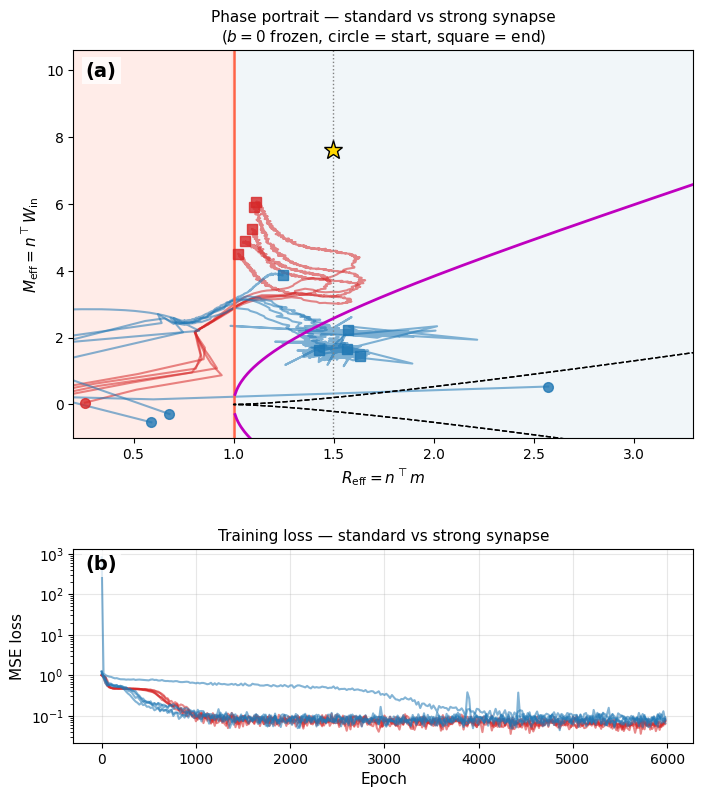

In [16]:
# ----------------------------------------------------------
# TA follow-up: strong synapse init vs standard init, b=0 frozen
# m ~ N(0, 1/N), n ~ N(0, 1)  vs  m ~ N(0, 1/N), n ~ N(0, 1/N)
# ----------------------------------------------------------
import math

N_rnn       = 100
n_seeds     = 5
n_epochs_s  = 6000
rec_s       = 20
epochs_ax_s = np.arange(n_epochs_s // rec_s) * rec_s

fig, axes = plt.subplots(2, 1, figsize=(8, 9),
                          gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.38})

header = f"{'init':>22}  {'seed':>4}  {'R_init':>7}  {'M_init':>7}  {'R_fin':>7}  {'M_fin':>7}  {'loss':>8}  {'bist':>4}"
print(header)
print('-' * len(header))

for init_label, n_std, col in [
        ('standard  n~N(0,1/N)', 1/math.sqrt(N_rnn), 'C3'),
        ('strong    n~N(0,1)',    1.0,                 'C0'),
]:
    R_trajs, M_trajs, L_trajs = [], [], []
    for seed in range(n_seeds):
        torch.manual_seed(seed)
        rnn_s = RankOneRNN(N=N_rnn, alpha=0.5, freeze_b=True)
        with torch.no_grad():
            rnn_s.n.data = torch.randn(N_rnn, 1) * n_std
        R_init, M_init = get_eff(rnn_s)

        opt_s = torch.optim.Adam(rnn_s.parameters(), lr=1e-3)
        R_t, M_t, L_t = [], [], []
        for epoch in range(n_epochs_s):
            if epoch % rec_s == 0:
                R, M = get_eff(rnn_s)
                R_t.append(R); M_t.append(M)
            opt_s.zero_grad()
            loss = ((rnn_s(U_rnn) - O_rnn)**2).mean()
            loss.backward()
            opt_s.step()
            if epoch % rec_s == 0:
                L_t.append(loss.item())

        R_fin, M_fin = get_eff(rnn_s)
        with torch.no_grad():
            loss_fin = ((rnn_s(U_rnn) - O_rnn)**2).mean().item()
        bistable = chr(10003) if R_fin > 1.0 else chr(10007)
        print(f"{init_label:>22}  {seed:>4}  {R_init:7.3f}  {M_init:7.3f}  "
              f"{R_fin:7.3f}  {M_fin:7.3f}  {loss_fin:8.5f}  {bistable:>4}")
        R_trajs.append(np.array(R_t))
        M_trajs.append(np.array(M_t))
        L_trajs.append(np.array(L_t))

    for j, (Rt, Mt, Lt) in enumerate(zip(R_trajs, M_trajs, L_trajs)):
        axes[0].plot(Rt, Mt, color=col, alpha=0.55, linewidth=1.5)
        axes[0].plot(Rt[0],  Mt[0],  'o', color=col, markersize=7, alpha=0.8, zorder=5)
        axes[0].plot(Rt[-1], Mt[-1], 's', color=col, markersize=7, alpha=0.8, zorder=5)
        axes[1].plot(epochs_ax_s[:len(Lt)], Lt, color=col, alpha=0.55, linewidth=1.5)

FS_LABEL = 11; FS_TICK = 10; FS_PANEL = 14
make_background_rnn(axes[0], R_base_rnn, M_base_rnn,
                    xlim=xlim_r, ylim=(-1, M_base_rnn + 3), alpha_rnn=rnn_base.alpha)
axes[0].set_xlabel(r'$R_\mathrm{eff} = n^\top m$', fontsize=FS_LABEL)
axes[0].set_ylabel(r'$M_\mathrm{eff} = n^\top W_\mathrm{in}$', fontsize=FS_LABEL)
axes[0].tick_params(labelsize=FS_TICK)
axes[0].set_title('Phase portrait — standard vs strong synapse\n'
                  r'($b=0$ frozen, circle = start, square = end)', fontsize=FS_LABEL)
axes[0].text(0.02, 0.97, '(a)', transform=axes[0].transAxes, fontsize=FS_PANEL,
             fontweight='bold', va='top', ha='left',
             bbox=dict(boxstyle='square,pad=0.2', facecolor='white', alpha=0.75, edgecolor='none'))

axes[1].set_xlabel('Epoch', fontsize=FS_LABEL)
axes[1].set_ylabel('MSE loss', fontsize=FS_LABEL)
axes[1].tick_params(labelsize=FS_TICK)
axes[1].set_yscale('log')
axes[1].set_title('Training loss — standard vs strong synapse', fontsize=FS_LABEL)
axes[1].grid(True, alpha=0.3)
axes[1].text(0.02, 0.97, '(b)', transform=axes[1].transAxes, fontsize=FS_PANEL,
             fontweight='bold', va='top', ha='left',
             bbox=dict(boxstyle='square,pad=0.2', facecolor='white', alpha=0.75, edgecolor='none'))

plt.savefig('plots/rnn_strong_synapse_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ----------------------------------------------------------
# RNN — perturbation setup (shared across all experiments)
# For each test R, compute M_crit(R) and start ε above/below.
# ----------------------------------------------------------

def mcrit_at_R(R_val, alpha_rnn=0.5):
    if R_val <= 1.0:
        return np.nan
    kappa = 0.5
    for _ in range(500):
        kappa = np.tanh(R_val * kappa)
    ratio = (1 - alpha_rnn) / alpha_rnn * kappa
    if abs(ratio) >= 1.0:
        return np.nan
    return float(np.arctanh(kappa) + np.arctanh(ratio))

eps     = 0.3
R_tests = [1.3, 1.5, 1.7]
colors  = ['C1', 'C4', 'C0']

perturbs_rnn = []
for R_test, col in zip(R_tests, colors):
    mc = mcrit_at_R(R_test, alpha_rnn=rnn_base.alpha)
    dR = R_test - R_base_rnn
    for sign, side in [(+1, 'above'), (-1, 'below')]:
        dM = (mc + sign * eps) - M_base_rnn
        perturbs_rnn.append((dR, dM, f'R={R_test:.1f}, {side} (M_crit={mc:.2f})', col))

print('Perturbation setup ready.')
for dR, dM, label, _ in perturbs_rnn:
    print(f'  {label:>36}  dR={dR:+.3f}  dM={dM:+.3f}')


Perturbation setup ready.
            R=1.3, above (M_crit=1.96)  dR=-0.198  dM=-5.345
            R=1.3, below (M_crit=1.96)  dR=-0.198  dM=-5.945
            R=1.5, above (M_crit=2.58)  dR=+0.002  dM=-4.724
            R=1.5, below (M_crit=2.58)  dR=+0.002  dM=-5.324
            R=1.7, above (M_crit=3.11)  dR=+0.202  dM=-4.191
            R=1.7, below (M_crit=3.11)  dR=+0.202  dM=-4.791


In [14]:
# ----------------------------------------------------------
# RNN — precompute background grid (shared by all experiment plots)
# ----------------------------------------------------------
from matplotlib.colors import LogNorm

U_gf_rnn = U_rnn[:8]
O_gf_rnn = O_rnn[:8]

xlim_r = (0.2, R_base_rnn + 1.8)
ylim_r = (M_base_rnn - 7, M_base_rnn + 3)

R_rng = np.linspace(xlim_r[0], xlim_r[1], 22)
M_rng = np.linspace(ylim_r[0], ylim_r[1], 22)
gr_r, gm_r, lf_r = compute_grad_field_rnn(rnn_base, U_gf_rnn, O_gf_rnn, R_rng, M_rng)
RR_r, MM_r = np.meshgrid(R_rng, M_rng)

lf_r_safe = np.maximum(lf_r, 1e-6)
lf_r_log  = np.log10(lf_r_safe)
lv_r = np.logspace(np.log10(lf_r_safe.min()), np.log10(lf_r_safe.max()), 30)

R_flip_r, M_flip_r = flip_boundary_rnn(np.linspace(xlim_r[0], xlim_r[1], 400),
                                        alpha_rnn=rnn_base.alpha)
y_fc = np.linspace(-2.5, 2.5, 400)
R_fc, M_fc = fold_curve_rnn(y_fc)

print('Background grid ready.')


Background grid ready.


## Experiment 1 — Bias NOT frozen during retraining (original approach)

Start from `rnn_base_raw` (b **not** zeroed after base training). During retraining, b is a free parameter alongside m and win. This is the setup before we identified the b_eff offset issue. The b drift can shift M_eff and obscure the true flip boundary.


                               label  R_start  M_start    R_end    M_end      loss    time
----------------------------------------------------------------------------------------------------
          R=1.3, above (M_crit=1.96)    1.300    2.255    1.463    5.852   0.06257  196.3s
          R=1.3, below (M_crit=1.96)    1.300    1.655    1.454    5.669   0.07077  195.7s
          R=1.5, above (M_crit=2.58)    1.500    2.876    1.505    6.077   0.08464  196.0s
          R=1.5, below (M_crit=2.58)    1.500    2.276    1.473    5.833   0.07817  196.7s
          R=1.7, above (M_crit=3.11)    1.700    3.410    1.558    6.234   0.07420  197.4s
          R=1.7, below (M_crit=3.11)    1.700    2.810    1.547    6.019   0.06017  197.7s

Total: 1179.8s  (196.6s/trajectory)


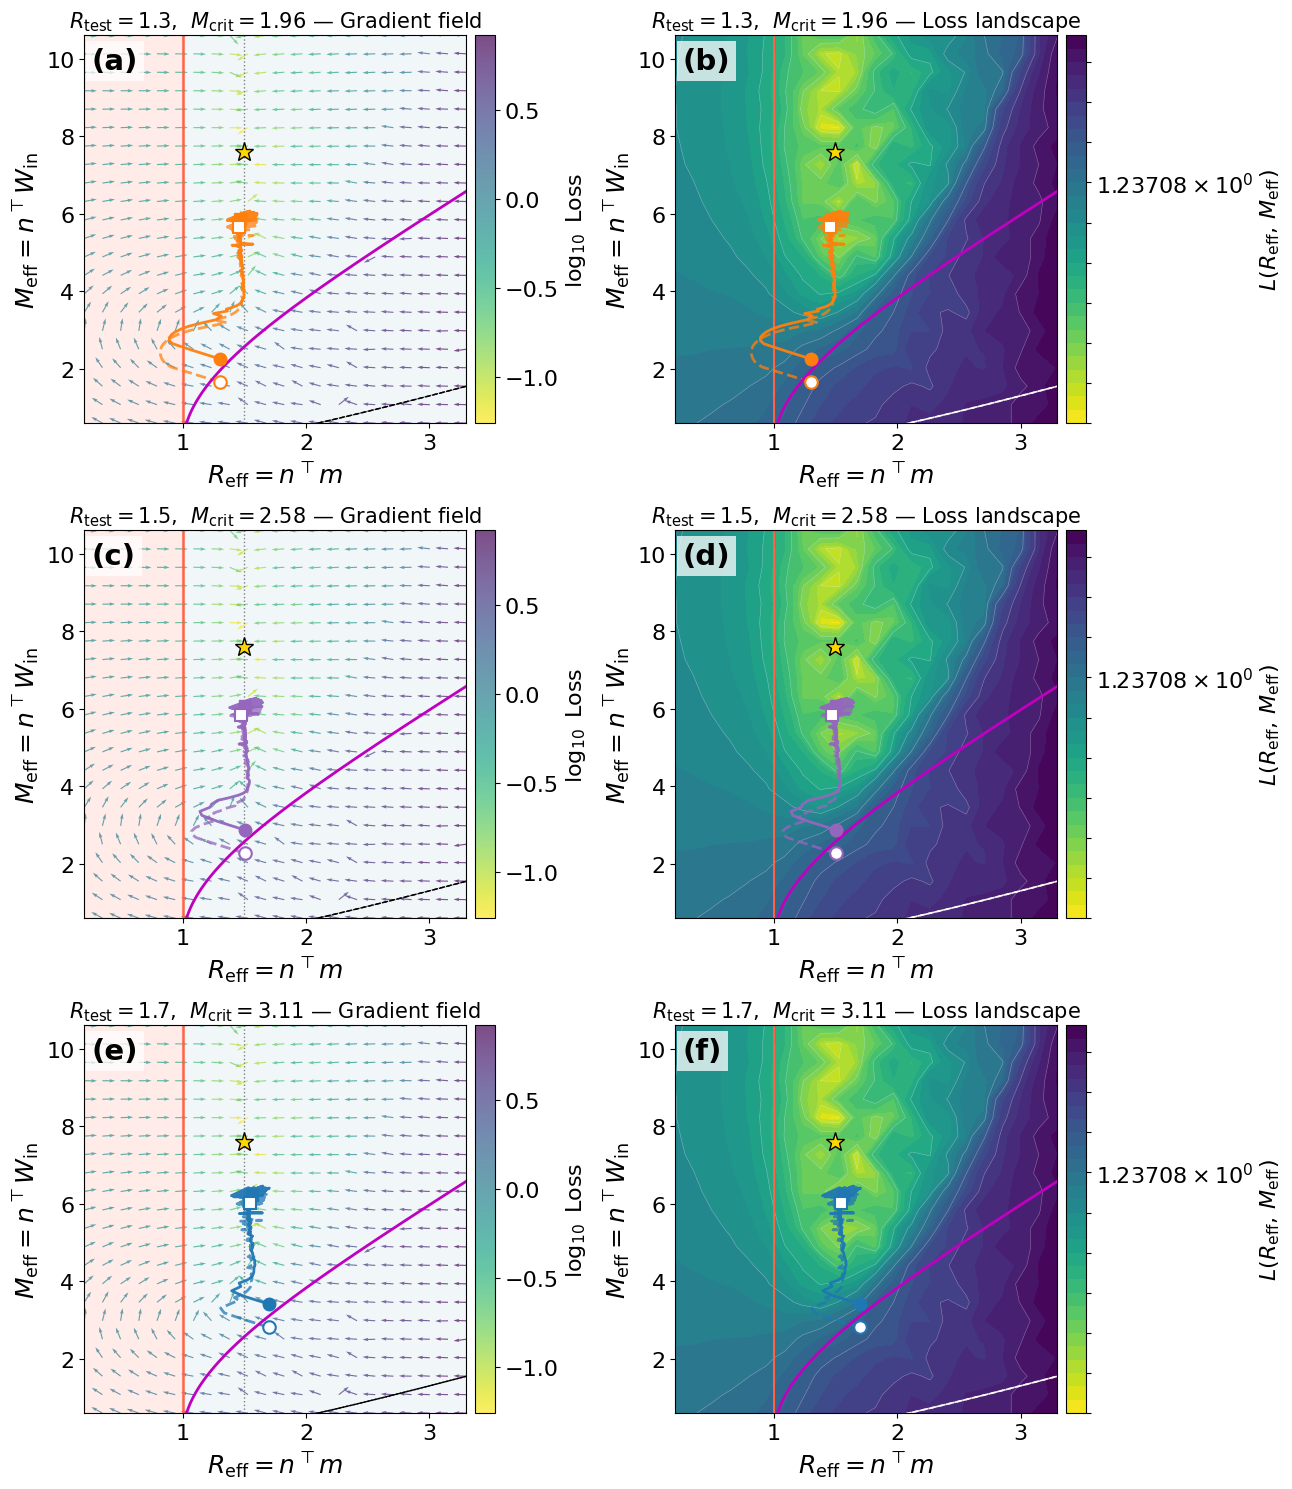

In [17]:
# Experiment 1: b NOT frozen (original approach, before b_eff correction)
# rnn_base_raw has b_eff != 0; b remains a free parameter during retraining.
trajs_exp1 = run_experiment(rnn_base_raw, perturbs_rnn, U_rnn, O_rnn,
                             steps=4000, lr=2e-3, freeze_b=False)
plot_reinit_grid(trajs_exp1,
                 title='Exp 1: b free during retraining (no b_eff correction)',
                 save_path='plots/rnn_exp1_b_free.png')


## Experiment 2 — Current approach: b_eff zeroed + b frozen during retraining

Start from `rnn_base` (b_eff zeroed after base training). During retraining, b is frozen so b_eff=0 is maintained as an invariant. Gradient projection onto n̂ keeps the trajectory strictly in the (R_eff, M_eff) plane. This is the corrected baseline.


                               label  R_start  M_start    R_end    M_end      loss    time
----------------------------------------------------------------------------------------------------
    step    0  t=  0.1s  R=1.300  M=2.255  loss=1.5887
    step    1  t=  0.2s  R=1.081  M=2.474  loss=1.1018
    step    2  t=  0.2s  R=1.018  M=2.578  loss=1.0274
    step    3  t=  0.3s  R=1.002  M=2.654  loss=0.9935
    step    4  t=  0.3s  R=0.997  M=2.722  loss=0.9633
    step    5  t=  0.4s  R=1.005  M=2.785  loss=0.9307
    step    6  t=  0.5s  R=1.025  M=2.846  loss=0.9017
    step    7  t=  0.5s  R=1.057  M=2.908  loss=0.8572
    step    8  t=  0.5s  R=1.103  M=2.971  loss=0.8103
    step    9  t=  0.6s  R=1.160  M=3.037  loss=0.7439
    step   10  t=  0.6s  R=1.222  M=3.107  loss=0.6602
    step   11  t=  0.7s  R=1.287  M=3.182  loss=0.5785
    step   12  t=  0.7s  R=1.344  M=3.256  loss=0.5085
    step   13  t=  0.8s  R=1.368  M=3.324  loss=0.4716
    step   14  t=  0.8s  R=1.382  M=3.

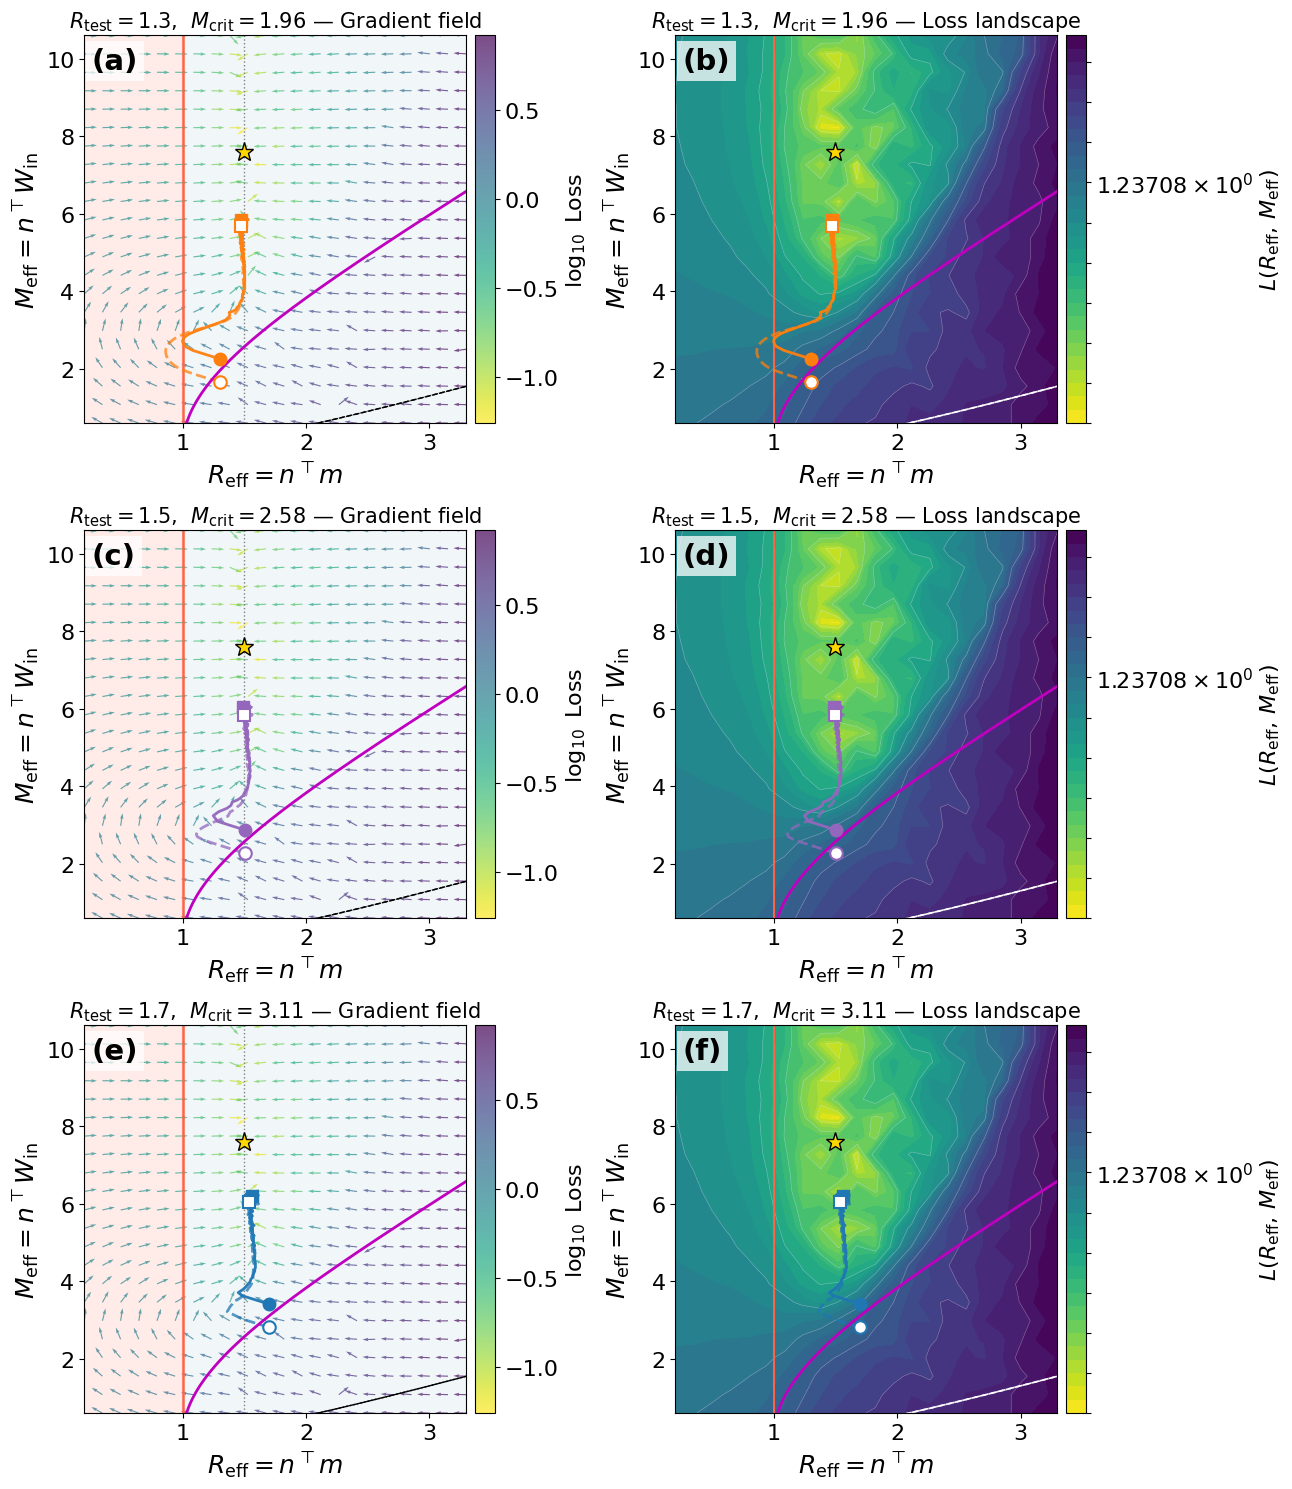

In [18]:
# Experiment 2: current approach — b_eff zeroed, b frozen during retraining
_vsteps = set(range(0, 30, 1)) | {500, 750, 1000, 1250, 1500, 1750}
trajs_exp2 = run_experiment(rnn_base, perturbs_rnn, U_rnn, O_rnn,
                             steps=2000, lr=2e-3, freeze_b=True,
                             verbose_steps=_vsteps)
plot_reinit_grid(trajs_exp2,
                 title='Exp 2: b frozen (b_eff=0 invariant, corrected baseline)',
                 save_path='plots/rnn_exp2_b_frozen.png')

## Experiment 3 — Separate learning rates for R_eff and M_eff coordinates

Same as Exp 2, but m (controls R_eff) and win (controls M_eff) use separate RMSprop optimizers with different learning rates. A higher lr for win gives M_eff more aggressive updates relative to R_eff, potentially allowing M_eff to reach the base value even when the loss landscape is asymmetric.

                               label  R_start  M_start    R_end    M_end      loss    time
----------------------------------------------------------------------------------------------------
    step    0  t=  0.1s  R=1.300  M=2.255  loss=1.5719
    step    1  t=  0.1s  R=1.081  M=3.348  loss=0.6617
    step    2  t=  0.2s  R=1.178  M=3.689  loss=0.4585
    step    3  t=  0.2s  R=1.272  M=3.945  loss=0.3071
    step    4  t=  0.3s  R=1.342  M=4.129  loss=0.2304
    step    5  t=  0.3s  R=1.388  M=4.273  loss=0.1840
    step    6  t=  0.4s  R=1.420  M=4.391  loss=0.1565
    step    7  t=  0.4s  R=1.443  M=4.493  loss=0.1721
    step    8  t=  0.5s  R=1.456  M=4.581  loss=0.1636
    step    9  t=  0.5s  R=1.467  M=4.660  loss=0.1435
    step   10  t=  0.6s  R=1.474  M=4.731  loss=0.1466
    step   11  t=  0.6s  R=1.478  M=4.796  loss=0.1426
    step   12  t=  0.6s  R=1.481  M=4.854  loss=0.1292
    step   13  t=  0.7s  R=1.483  M=4.909  loss=0.1257
    step   14  t=  0.7s  R=1.485  M=4.

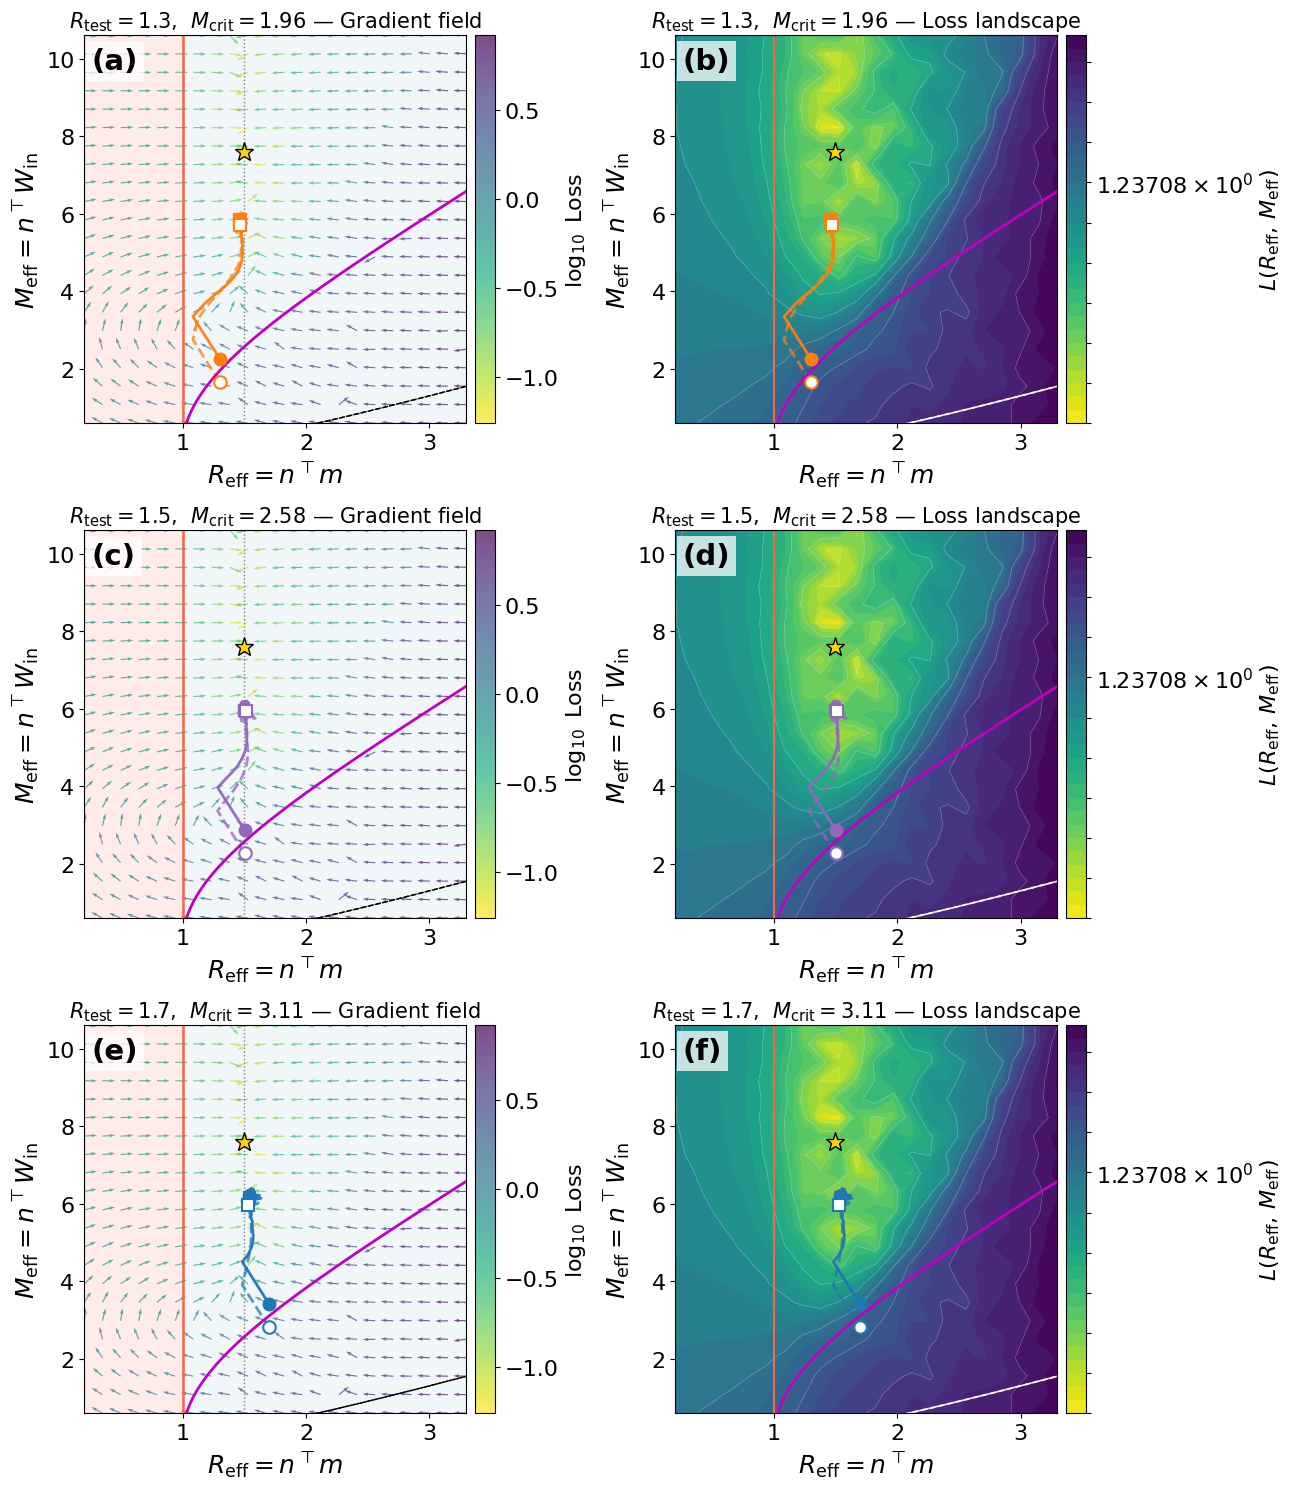

In [19]:
# Experiment 3: separate learning rates — lr=2e-3 for m (R_eff), lr_M=1e-2 for win (M_eff)
_vsteps = set(range(0, 30, 1)) | {500, 750, 1000, 1250, 1500, 1750}
trajs_exp3 = run_experiment(rnn_base, perturbs_rnn, U_rnn, O_rnn,
                             steps=2000, lr=2e-3, freeze_b=True,
                             lr_M=1e-2, verbose_steps=_vsteps)
plot_reinit_grid(trajs_exp3,
                 title='Exp 3: separate lr — m lr=2e-3, win lr=1e-2',
                 save_path='plots/rnn_exp3_sep_lr.png')

## Base training without bias — hyperparameter sweep

Systematic check: can b=0 frozen base training reach R_eff > 1 (bistable) under any reasonable hyperparameter setting? Sweeps 5 seeds × 4 learning rates (20 runs), plots R_eff trajectories over epochs per lr, and reports final (R_eff, M_eff, loss) for every run.


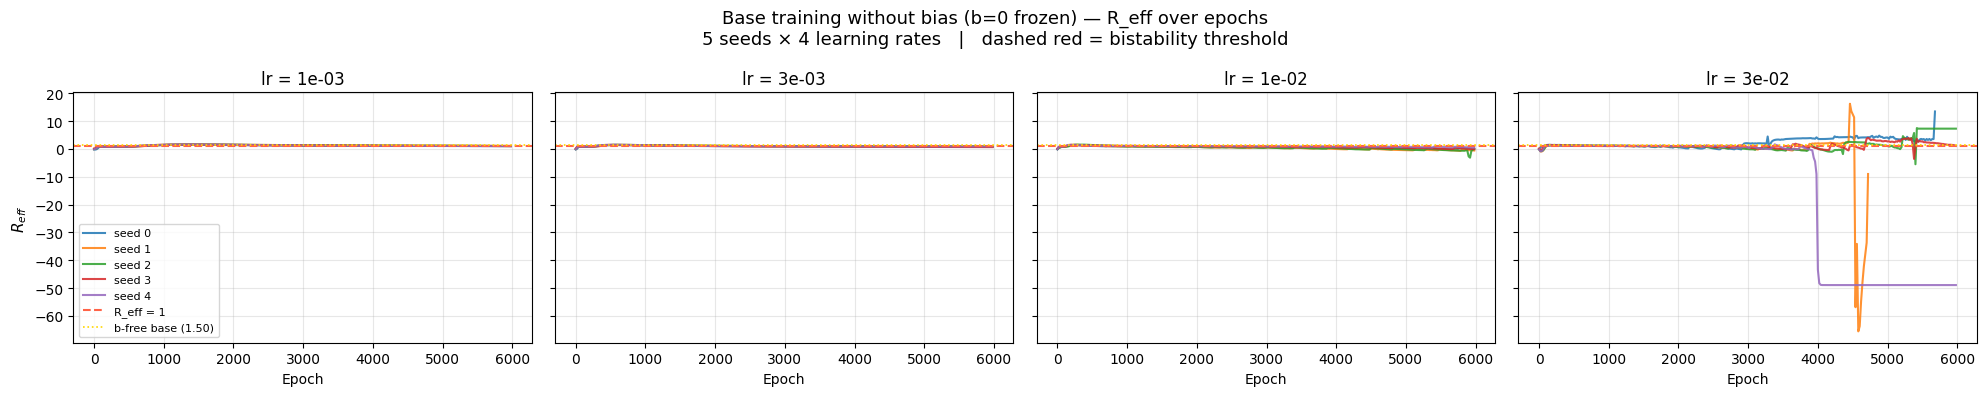

Saved: plots/rnn_base_no_bias_sweep.png

      lr   seed    R_fin    M_fin      loss  bistable?
----------------------------------------------------
   1e-03      0   1.0223   5.5584   0.04920        YES
   1e-03      1   1.0991   4.6698   0.05285        YES
   1e-03      2   1.0514   5.5034   0.05692        YES
   1e-03      3   1.0335   5.2527   0.05319        YES
   1e-03      4   1.0108   4.3416   0.05075        YES

   3e-03      0   0.8641   6.2268   0.04956         no
   3e-03      1   0.8753   5.8005   0.04654         no
   3e-03      2   0.8617   5.9827   0.05223         no
   3e-03      3   0.6618   6.3914   0.04745         no
   3e-03      4   0.8791   5.3353   0.04965         no

   1e-02      0  -0.2175   8.1195   0.05430         no
   1e-02      1  -0.5814   6.8497   0.04874         no
   1e-02      2  -0.0227   5.3247   0.07504         no
   1e-02      3  -0.0526   7.5666   0.04809         no
   1e-02      4   0.4652   6.8761   0.04673         no

   3e-02      0      na

In [ ]:
# ----------------------------------------------------------
# Base training without bias — 5 seeds × 4 learning rates
# ----------------------------------------------------------
seeds   = [0, 1, 2, 3, 4]
lrs     = [1e-3, 3e-3, 1e-2, 3e-2]
n_epochs = 6000
record_every = 20

seed_colors = ['C0', 'C1', 'C2', 'C3', 'C4']

# Run all 20 combinations; store R_eff trajectories + final values
results = {}   # (lr, seed) -> {'R_traj', 'M_traj', 'L_traj', 'R_fin', 'M_fin', 'loss_fin'}
for lr_val in lrs:
    for seed in seeds:
        torch.manual_seed(seed)
        rnn_s = RankOneRNN(N=100, alpha=0.5, freeze_b=True)
        opt_s = torch.optim.Adam(rnn_s.parameters(), lr=lr_val)
        R_t, M_t, L_t = [], [], []
        for epoch in range(n_epochs):
            if epoch % record_every == 0:
                R, M = get_eff(rnn_s)
                R_t.append(R); M_t.append(M)
            opt_s.zero_grad()
            loss = ((rnn_s(U_rnn) - O_rnn)**2).mean()
            loss.backward()
            opt_s.step()
            if epoch % record_every == 0:
                L_t.append(loss.item())
        R_fin, M_fin = get_eff(rnn_s)
        with torch.no_grad():
            loss_fin = ((rnn_s(U_rnn) - O_rnn)**2).mean().item()
        results[(lr_val, seed)] = dict(
            R_traj=np.array(R_t), M_traj=np.array(M_t), L_traj=np.array(L_t),
            R_fin=R_fin, M_fin=M_fin, loss_fin=loss_fin)

# ---- Plot: R_eff trajectories (one panel per lr) ----
fig, axes = plt.subplots(1, len(lrs), figsize=(5 * len(lrs), 4), sharey=True)
epochs_axis = np.arange(n_epochs // record_every) * record_every

for ax, lr_val in zip(axes, lrs):
    for seed, sc in zip(seeds, seed_colors):
        R_t = results[(lr_val, seed)]['R_traj']
        ax.plot(epochs_axis[:len(R_t)], R_t, color=sc, linewidth=1.5,
                alpha=0.85, label=f'seed {seed}')
    ax.axhline(1.0, color='tomato', linewidth=1.5, linestyle='--', label='R_eff = 1')
    ax.axhline(R_base_rnn, color='gold', linewidth=1.2, linestyle=':',
               label=f'b-free base ({R_base_rnn:.2f})')
    ax.set_title(f'lr = {lr_val:.0e}', fontsize=12)
    ax.set_xlabel('Epoch', fontsize=10)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('$R_{eff}$', fontsize=11)
axes[0].legend(fontsize=8)
fig.suptitle('Base training without bias (b=0 frozen) — R_eff over epochs\n'
             '5 seeds × 4 learning rates   |   dashed red = bistability threshold',
             fontsize=13)
plt.tight_layout()
plt.savefig('plots/rnn_base_no_bias_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plots/rnn_base_no_bias_sweep.png')

# ---- Summary table ----
print(f'\n{"lr":>8}  {"seed":>5}  {"R_fin":>7}  {"M_fin":>7}  {"loss":>8}  {"bistable?":>9}')
print('-' * 52)
for lr_val in lrs:
    for seed in seeds:
        r = results[(lr_val, seed)]
        bistable = 'YES' if r['R_fin'] > 1.0 else 'no'
        print(f'{lr_val:8.0e}  {seed:5d}  {r["R_fin"]:7.4f}  {r["M_fin"]:7.4f}'
              f'  {r["loss_fin"]:8.5f}  {bistable:>9}')
    print()
